In [1]:
""" Fitting squeezing model to data to recover r and phi

Import 2D char fn, assume Im part is 0
Normalise and baseline correct 2D char fn
Optional: Apply 2D FFT conversion to recover 2D wigner function.
    - check defn used by GC and SS/OB
Fit squeezing model to 2D wigner function
"""

from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import graph_style as gs
import fig_helper as fh
gs.set_graph_style(1)

base_cmap = sns.diverging_palette(230, 15, as_cmap=True)
x_map = np.linspace(0, 1, 256)
# Accelerate movement away from white
gamma = 0.8
x_remap = 0.5 + 0.5 * np.sign(x_map - 0.5) * (2 * np.abs(x_map - 0.5))**gamma
cmap = LinearSegmentedColormap.from_list(
    "enhanced_diverging",
    base_cmap(x_remap)
)
# fit 2D squeezing model to 2D char fn data
#X(Beta)=<D(Beta)>
def squeezing_model(xy, r, phi):
    """ From Sebastian thesis eqn 2.54"""
    x, y = xy
    absB = np.sqrt(x**2 + y**2)
    argB = np.arctan2(y, x)
    X = np.exp(-0.5 * absB**2 * (np.exp(2*r) * np.cos(argB - phi/2)**2 + np.exp(-2*r) * np.sin(argB - phi/2)**2))
    return X

def get_char(rid, day, Zvalue=False, flip_p =False):
    f = fh.load_data(rid=rid, day=day)

    if flip_p:
        z = 1-np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p'])
    else:
        z = np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p'])
    z_err = np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_err'])

    x = np.array(f['datasets'][f'ndscan.rid_{rid}.points.axis_0'])
    y = np.array(f['datasets'][f'ndscan.rid_{rid}.points.axis_1'])

    # Gets x, y axis and obtains a 2d bright_frac array
    X = list(np.unique(x))
    Y = list(np.unique(y))

    x = np.reshape(x, (len(X), len(Y)))
    y = np.reshape(y, (len(X), len(Y)))
    z = np.reshape(z, (len(X), len(Y)))
    z_err = np.reshape(z_err, (len(X), len(Y)))
    
    s = np.argsort(x[0,:])
    t= np.argsort(y[:,0])

    z = z[...,s]
    z = z[t,...]
             
    z_err = z_err[...,s]
    z_err = z_err[t,...]

    if Zvalue:
        z = 2*z -1
        z_err = 2*z_err

    fdg = 22.785/24.359 # difference in split calibration between DW and GC
    return np.array(X)*fdg, np.array(Y)*fdg, z, z_err


Fitted r: 0.902 ± 0.020, phi: 0.335 rad


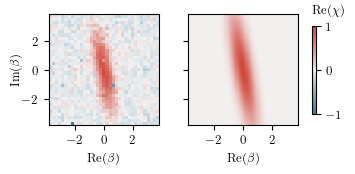

In [3]:
day = "2026-08-17"
rid = 138067

x,y,z,z_err = get_char(rid, day, Zvalue=True)

x_g, y_g = np.meshgrid(x, y)

popt, pcov = curve_fit(squeezing_model, (x_g.flatten(), y_g.flatten()), z.flatten(), p0=[0.5, 0.5], sigma=z_err.flatten())
r = popt[0]
phi = popt[1]
r_err = np.sqrt(pcov[0,0])
print(f"Fitted r: {r:.3f} ± {r_err:.3f}, phi: {phi:.3f} rad")

x_fit = np.linspace(np.min(x), np.max(x), 100)
y_fit = np.linspace(np.min(y), np.max(y), 100)
x_fit, y_fit = np.meshgrid(x_fit, y_fit)
z_fit = squeezing_model((x_fit, y_fit), r, phi)



fig_width = gs.get_fig_width()/1.7
fig_height = fig_width / 2.1
fig, ax = plt.subplots(1, 2, figsize=(fig_width, fig_height), constrained_layout=True)
ax[0].pcolormesh(x, y, z, cmap=cmap, vmin=-1, vmax=1, rasterized=False)
ax[1].pcolormesh(x_fit, y_fit, z_fit, cmap=cmap, vmin=-1, vmax=1, rasterized=False)
for a in ax:
    a.set_xlabel("$\\mathrm{Re}(\\beta)$")
    a.set_aspect('equal')
    a.set_xticks([-2, 0, 2])
    a.set_yticks([-2, 0, 2])
    a.grid(False)
ax[0].set_ylabel("$\\mathrm{Im}(\\beta)$", labelpad=0)
ax[1].set_yticklabels([])
cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.15, pad=0.05, aspect=20, shrink=0.8)
#set ticks on cbar
cbar.set_ticks([-1, 0, 1])
# set cbar label on top of cbar, move it up and rotate it to horizontal and move to left
cbar.set_label("$\\mathrm{Re}(\\chi)$", labelpad=-10, rotation=0, y=1.25, x=+0.5)
fname = "..\\..\\pdf_figure\\ch6\\sqz_char.pdf"
# plt.savefig(fname, transparent=True, dpi=300)


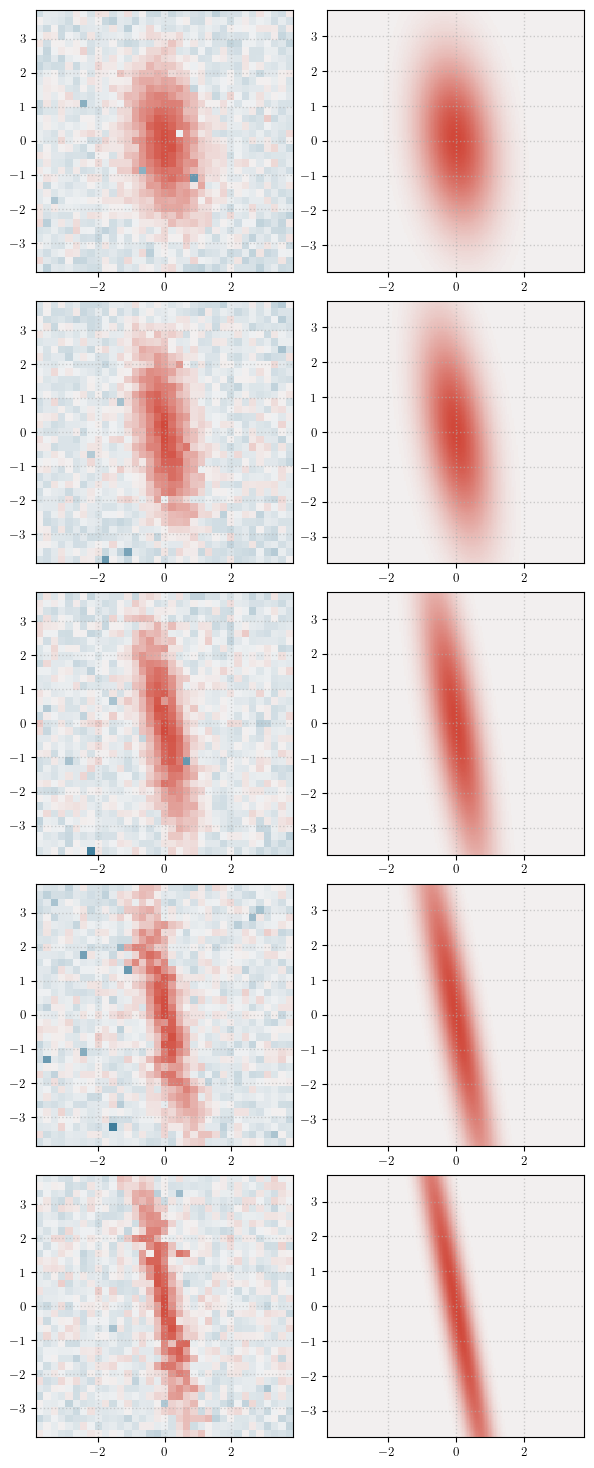

In [4]:

dates = ["2026-08-18", "2026-08-17"]
rids = [138069, 138068, 138067, 138066, 138065]#, 138064]
taus = [50, 100, 150, 200, 250]#, 250]

r_arr = []
r_err_arr = []
phi_arr = []
phi_err_arr = []
z_exp_arr = []
z_fit_arr = []

x_range = np.linspace(np.min(x), np.max(x), 200)
y_range = np.linspace(np.min(y), np.max(y), 200)
x_fit, y_fit = np.meshgrid(x_range, y_range)
for rid, tau in zip(rids, taus):
    for day in dates:
        try:
            x,y,z,z_err = get_char(rid, day, Zvalue=True)
        except Exception as e:
            pass
    z_exp_arr.append(z)

    x_g, y_g = np.meshgrid(x, y)

    popt, pcov = curve_fit(squeezing_model, (x_g.flatten(), y_g.flatten()), z.flatten(), p0=[0.5, 0.5], sigma=z_err.flatten())
    r = popt[0]
    phi = popt[1]
    r_arr.append(r)
    r_err_arr.append(np.sqrt(pcov[0,0]))
    phi_arr.append(phi)
    phi_err_arr.append(np.sqrt(pcov[1,1]))
    z_fit = squeezing_model((x_fit, y_fit), r, phi)
    z_fit_arr.append(z_fit)

num_rids = len(rids)
fig_width = gs.get_fig_width()
fig_height = fig_width * num_rids / 2
fig, ax = plt.subplots(num_rids, 2, figsize=(fig_width, fig_height), constrained_layout=True)
for i, (z_exp, z_fit) in enumerate(zip(z_exp_arr, z_fit_arr)):
    ax[i, 0].pcolormesh(x, y, z_exp, shading='auto', cmap=cmap, vmin=-1, vmax=1)
    ax[i, 1].pcolormesh(x_fit, y_fit, z_fit, shading='auto', cmap=cmap, vmin=-1, vmax=1)

Measured omega: 2pi 0.7390 +- 0.0112 kHz
Estimated omega: 2pi 0.8564 + 0.0918 - 0.0872 kHz


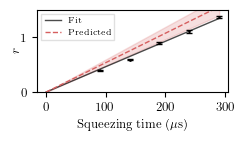

In [5]:
def linear_fit(x, m):
    return m*x 

t_ramp = 40
t_corrected = np.array(taus) + t_ramp
popt_r, pcov_r = curve_fit(linear_fit, t_corrected, r_arr)
popt_phi, pcov_phi = curve_fit(linear_fit, t_corrected, phi_arr)
x_fit_r = np.linspace(0, np.max(t_corrected), 100)
y_fit_r = linear_fit(x_fit_r, *popt_r)
x_fit_phi = np.linspace(0, np.max(t_corrected), 100)
y_fit_phi = linear_fit(x_fit_phi, *popt_phi)
meas_omega = popt_r[0]
meas_omega_err = np.sqrt(pcov_r[0,0])
print(f"Measured omega: 2pi {meas_omega*1000/(2*np.pi):.4f} +- {meas_omega_err*1000/(2*np.pi):.4f} kHz")

fdg = np.sqrt(26.5/40)
omega_split = 7.253 # MHz
omega_split_err = 0.379 # MHz
est_omega = fdg*omega_split**2*2*np.pi/50 / 1000 # in MHz
est_omega_max = fdg*(omega_split + omega_split_err)**2*2*np.pi/50 / 1000 # in MHz
est_omega_min = fdg*(omega_split - omega_split_err)**2*2*np.pi/50 / 1000 # in MHz
print(f"Estimated omega: 2pi {est_omega*1000/(2*np.pi):.4f} + {(est_omega_max - est_omega)*1000/(2*np.pi):.4f} - {(est_omega - est_omega_min)*1000/(2*np.pi):.4f} kHz")
est_r_max = est_omega_max *x_fit_r
est_r_min = est_omega_min * x_fit_r
est_r = est_omega * x_fit_r



fig_width = gs.get_fig_width()/2.5
fig_height = fig_width / 1.8
fig, ax = plt.subplots(1,1, figsize=(fig_width, fig_height), constrained_layout=True)
ax.errorbar(t_corrected, r_arr, yerr=r_err_arr, color="black", linestyle='None', marker='^', markersize=1, capsize=2)
ax.plot(x_fit_r, y_fit_r, color="black", label=f'Fit', linestyle='-', alpha = gs.get_alpha())
ax.plot(x_fit_r, est_r, label=f'Predicted', linestyle='--', color=gs.get_color(2))
ax.fill_between(x_fit_r, est_r_max, est_r_min, color=gs.get_color(2), alpha=0.2)
ax.set_ylim(0, max(r_arr)*1.1)
ax.legend()
ax.set_xlabel("Squeezing time ($\\mu$s)")
ax.set_ylabel("$r$", labelpad=0)
ax.grid(False)

fname = "..\\..\\pdf_figure\\ch6\\sqz_r.pdf"
# make transparent
# plt.savefig(fname, transparent=True)



Fitted omega_sdf: 2pi 7.253 ± 0.379 kHz
45.57173855044345
Fitted A: 0.960 ± 0.025


Text(0, 0.5, '$\\langle Z \\rangle$')

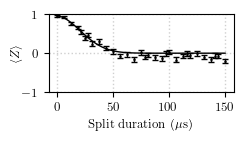

In [15]:
""" split exp, rid = 138050 """

def get_split(rid, day):
    f = fh.load_data(rid=rid, day=day)

    p = np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p'])
    p_err = np.array(f['datasets'][f'ndscan.rid_{rid}.points.channel_measurement_camera_readout_p_err'])

    t = np.array(f['datasets'][f'ndscan.rid_{rid}.points.axis_0'])

    t_sorted = np.argsort(t)
    p = p[t_sorted]
    p_err = p_err[t_sorted]
    t = t[t_sorted]*10**6 # convert to us
    # remove points for t > 150
    mask = t <= 150
    t = t[mask]
    p = p[mask]
    p_err = p_err[mask]

    z = 2*p -1
    z_err = 2*p_err

    return z, z_err, t

def alpha(t, delta, omega_sdf):
    a = 0.5*omega_sdf*t * np.sinc(delta*t/2) # Is this factor 1/2 correct?
    return a

def split_model(tF, omega_sdf,A):
    tR = 1.4
    t = tF + tR
    delta = 0.
    a = alpha(t, delta, omega_sdf)
    return A*np.exp(-2*a**2)

rid = 138050
day = "2026-08-17"
z, z_err, t = get_split(rid, day)

popt_split, pcov_split = curve_fit(split_model, t, z, sigma=z_err, p0=[0.05, 1], bounds=([0, 0], [1, 1]))
omega_sdf = popt_split[0]
A = popt_split[1]
omega_sdf_err = np.sqrt(pcov_split[0,0])
A_err = np.sqrt(pcov_split[1,1])
print(f"Fitted omega_sdf: 2pi {omega_sdf*1000/(2*np.pi):.3f} ± {omega_sdf_err*1000/(2*np.pi):.3f} kHz")
print(omega_sdf*1000)
print(f"Fitted A: {A:.3f} ± {A_err:.3f}")

x_fit = np.linspace(0, np.max(t), 100)
y_fit = split_model(x_fit, *popt_split)

fig_width = gs.get_fig_width()/2.5
fig_height = fig_width / 1.8
fig, ax = plt.subplots(1,1, figsize=(fig_width, fig_height), constrained_layout=True)
ax.errorbar(t, z, yerr=z_err, color="black", linestyle='None', marker='^', markersize=1, capsize=2)
ax.plot(x_fit, y_fit, color="black", label=f'Fit: $\\omega_{{sdf}} = {omega_sdf:.3f}$', linestyle='-')
ax.set_ylim(-1, 1.)
ax.set_yticks([-1, 0, 1])
ax.set_xlabel("Split duration ($\\mu$s)")
ax.set_ylabel("$\\langle Z \\rangle$", labelpad=0)